# Task 0 — Part B: Tensor Warmup

Six problems, solved with **no `nn.Module` and no library shortcuts** — only broadcasting, masking, and basic tensor ops. The goal is fluency with every tool used in the rest of the project.


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
print('torch', torch.__version__)


torch 2.12.1+cpu


## Problem 1 — Masked mean

Given `x` of shape `(B, T, C)` and `y` of shape `(B, T)`, compute the mean of `x` across `T`, but only at positions where `y == 1`. Output `(B, C)`. No Python loops — pure broadcasting + masking.


In [2]:
def masked_mean(x, y):
    # x: (B, T, C), y: (B, T) with 0/1 entries -> (B, C)
    mask = (y == 1).to(x.dtype)            # (B, T)
    masked = x * mask.unsqueeze(-1)        # (B, T, C), zero out unwanted positions
    num = masked.sum(dim=1)                # (B, C)
    den = mask.sum(dim=1, keepdim=True).clamp(min=1.0)  # (B, 1), avoid div-by-zero
    return num / den

B, T, C = 4, 6, 3
x = torch.randn(B, T, C)
y = (torch.rand(B, T) > 0.5).long()
out = masked_mean(x, y)
print('output shape:', tuple(out.shape))

# Verify against an explicit per-batch loop (reference only).
ref = torch.stack([
    x[b][y[b] == 1].mean(0) if (y[b] == 1).any() else torch.zeros(C)
    for b in range(B)
])
print('matches loop reference:', torch.allclose(out, ref, atol=1e-6))


output shape: (4, 3)
matches loop reference: True


## Problem 2 — Softmax from scratch

Implement softmax using only `exp`, `sum`, and arithmetic; match `torch.softmax` to 1e-6.


In [3]:
def softmax(x, dim=-1):
    # Subtract the max for numerical stability (see writeup below).
    x_max = x.max(dim=dim, keepdim=True).values
    e = torch.exp(x - x_max)
    return e / e.sum(dim=dim, keepdim=True)

z = torch.randn(5, 7)
mine = softmax(z, dim=-1)
ref = torch.softmax(z, dim=-1)
print('max abs diff vs torch.softmax:', (mine - ref).abs().max().item())
print('matches to 1e-6:', torch.allclose(mine, ref, atol=1e-6))

# Demonstrate the stability problem: naive softmax on large logits -> NaN.
big = torch.tensor([1000.0, 1001.0, 1002.0])
naive = torch.exp(big) / torch.exp(big).sum()
print('naive softmax on large logits:', naive)        # nan, nan, nan
print('stable softmax on large logits:', softmax(big))


max abs diff vs torch.softmax: 5.960464477539063e-08
matches to 1e-6: True
naive softmax on large logits: tensor([nan, nan, nan])
stable softmax on large logits: tensor([0.0900, 0.2447, 0.6652])


**Why naive softmax is numerically unstable, and the fix.**

Softmax computes `exp(x_i) / sum_j exp(x_j)`. Floating point can only represent numbers up to about `3.4e38` (float32). If any logit is large — say `1000` — then `exp(1000)` overflows to `+inf`, and `inf / inf = NaN`, poisoning the whole output. Very negative logits underflow to `0`, which is less catastrophic but loses precision.

The standard fix is to subtract the per-row maximum before exponentiating: `softmax(x) = softmax(x - max(x))`. This is **mathematically identical** because the constant `exp(-max)` factors out of numerator and denominator and cancels. But now the largest exponent is `exp(0) = 1`, so nothing overflows. This is the same idea as the **log-sum-exp** trick, which reappears in the InfoNCE loss later in the project.


## Problem 3 — Attention scores two ways

Given `Q, K` of shape `(B, T, d)`, compute the scores `(B, T, T)` with `einsum` and with `@` + transpose, and verify they are equal.


In [4]:
B, T, d = 2, 5, 8
Q = torch.randn(B, T, d)
K = torch.randn(B, T, d)

scores_einsum = torch.einsum('btd,bsd->bts', Q, K)
scores_matmul = Q @ K.transpose(-2, -1)
print('shapes:', tuple(scores_einsum.shape), tuple(scores_matmul.shape))
print('max abs diff:', (scores_einsum - scores_matmul).abs().max().item())
print('exactly equal:', torch.equal(scores_einsum, scores_matmul))


shapes: (2, 5, 5) (2, 5, 5)
max abs diff: 0.0
exactly equal: True


## Problem 4 — Causal mask

Build a `(T, T)` mask that is `0` on and below the diagonal and `-inf` above it. Add it to an attention score matrix before softmax, then visualize the post-softmax attention for `T=8`.


mask (0 = visible, -inf = blocked):
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


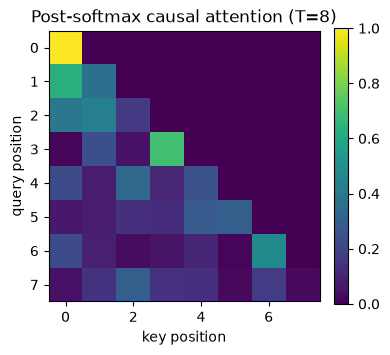

each row sums to 1: True
upper triangle is zero: True


In [5]:
T = 8
# 1s strictly above the diagonal -> those become -inf.
causal_mask = torch.triu(torch.ones(T, T), diagonal=1)
causal_mask = causal_mask.masked_fill(causal_mask == 1, float('-inf'))
print('mask (0 = visible, -inf = blocked):')
print(causal_mask)

scores = torch.randn(T, T)
attn = torch.softmax(scores + causal_mask, dim=-1)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(attn.detach(), cmap='viridis')
ax.set_title('Post-softmax causal attention (T=8)')
ax.set_xlabel('key position'); ax.set_ylabel('query position')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print('each row sums to 1:', torch.allclose(attn.sum(-1), torch.ones(T), atol=1e-6))
print('upper triangle is zero:', torch.allclose(attn.triu(1), torch.zeros(T, T), atol=1e-6))


## Problem 5 — LayerNorm from scratch

Normalize over the `C` dimension (per token, per batch), then apply learnable scale `gamma` and shift `beta`. Match `nn.LayerNorm` to 1e-5.


In [6]:
def layer_norm(x, gamma, beta, eps=1e-5):
    # x: (B, T, C); normalize over the last (feature) dim only.
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)  # population variance (matches nn)
    x_hat = (x - mean) / torch.sqrt(var + eps)
    return gamma * x_hat + beta

B, T, C = 2, 4, 16
x = torch.randn(B, T, C)
gamma = torch.randn(C)   # learnable scale (random here to test the general case)
beta = torch.randn(C)    # learnable shift

mine = layer_norm(x, gamma, beta)

ln = torch.nn.LayerNorm(C, eps=1e-5)
with torch.no_grad():
    ln.weight.copy_(gamma)
    ln.bias.copy_(beta)
ref = ln(x)
print('max abs diff vs nn.LayerNorm:', (mine - ref).abs().max().item())
print('matches to 1e-5:', torch.allclose(mine, ref, atol=1e-5))


max abs diff vs nn.LayerNorm: 4.76837158203125e-07
matches to 1e-5: True


## Problem 6 — Manual gradients

First `y = (x**2).sum()`: by hand `dy/dx_i = 2 x_i`. Then `y = softmax(x).sum()` and explain the shape of its gradient.


In [7]:
x = torch.randn(4, requires_grad=True)
y = (x ** 2).sum()
y.backward()
print('autograd grad :', x.grad)
print('manual  2*x   :', 2 * x.detach())
print('match         :', torch.allclose(x.grad, 2 * x.detach(), atol=1e-6))


autograd grad : tensor([1.7895, 4.1885, 1.1416, 1.9402])
manual  2*x   : tensor([1.7895, 4.1885, 1.1416, 1.9402])
match         : True


In [8]:
x2 = torch.randn(4, requires_grad=True)
y2 = torch.softmax(x2, dim=0).sum()
y2.backward()
print('softmax(x).sum() =', y2.item(), '(always 1.0 — probabilities sum to 1)')
print('grad =', x2.grad, '(all ~0)')
print('grad is ~zero:', torch.allclose(x2.grad, torch.zeros(4), atol=1e-6))


softmax(x).sum() = 1.0 (always 1.0 — probabilities sum to 1)
grad = tensor([0., 0., 0., 0.]) (all ~0)
grad is ~zero: True


**Why the softmax gradient is (almost exactly) zero.**

`softmax(x).sum()` is identically `1` for *every* input `x` — the probabilities always sum to one. A function that is constant has zero gradient everywhere, so `x.grad` is `0` (up to floating-point noise).

More formally, the softmax Jacobian is `∂p_i/∂x_j = p_i (δ_ij − p_j)`. The gradient of the sum `L = Σ_i p_i` is `∂L/∂x_j = Σ_i p_i (δ_ij − p_j) = p_j − p_j Σ_i p_i = p_j − p_j·1 = 0`. The two terms cancel exactly — which is the formal reason the gradient vanishes. We will use this same Jacobian identity in the Task 2 attention-gradient derivation.


---
All six problems solved with outputs above. ✅
